### Write Up

We started with a high-dimensional feature set that combined FA and various biological measures. Following the GitHub implementation, I applied Neighborhood Components Analysis (NCA) to the entire feature set to learn a distance metric tailored to our risk prediction task. Using this metric, I computed the average feature vector for our high-risk group (risk labels 2 and 3) and then calculated each subject’s distance to this high-risk prototype. By taking the reciprocal of this distance and normalizing it, I obtained a similarity score that served as the single predictor in our logistic regression model.

Our model performed impressively, achieving an average ROC AUC of 0.869 and an accuracy of 0.917 when evaluated via cross-validation. I also used bootstrap resampling to confirm these results and provide confidence intervals and a p-value for the AUC, reinforcing the robustness of our findings.

When it came to understanding which features were most important, I initially tried several methods. However, due to severe multicollinearity, some methods (like permutation importance) didn’t work as expected. To overcome this, I turned to hierarchical clustering on the Spearman rank-order correlation matrix (See reference  https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html#sphx-glr-auto-examples-inspection-plot-permutation-importance-multicollinear-py). By visually inspecting the dendrogram and setting a threshold (I chose somewhat arbitrarily), we grouped highly correlated features together. Then, within each cluster, we selected the feature with the highest permutation importance as the representative. We retrained our logistic regression model using only these representative features, and the performance remained similar.

# Data Preprocessing

In [50]:
import pandas as pd
import numpy as np
import os

# Read the Excel file
xlsx_path = '/Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/AD_DECODE_data3.xlsx'
df = pd.read_excel(xlsx_path)

# Filter out specific MRI_Exam values and drop rows with missing MRI_Exam
df = df[(df['MRI_Exam'] != '0') & (df['MRI_Exam'] != '4491') & (df['MRI_Exam'] != '3866')]
df = df.dropna(subset=['MRI_Exam'])

# Initialize dictionary
fa_dict = {}

# Set the base directory
base_dir = '/Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2'

# Loop through each MRI_Exam value
for exam in df['MRI_Exam']:
    try:
        exam_int = int(float(exam))  # Convert to integer, remove .0
        exam_str = str(exam_int).zfill(4)  # Pad with zeros to 4 digits
        subject_id = f"{exam_str}"
        
        fa_path = os.path.join(base_dir, f"S0{subject_id}_columns_1mm", f"S0{subject_id}_fa.csv")
        
        if os.path.exists(fa_path):
            fa_values = np.loadtxt(fa_path, delimiter=',')
            fa_dict[subject_id] = fa_values
        else:
            print(f"File not found: {fa_path}")
    except Exception as e:
        print(f"Error with MRI_Exam = {exam}: {e}")


File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02469_columns_1mm/S02469_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02289_columns_1mm/S02289_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02266_columns_1mm/S02266_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02686_columns_1mm/S02686_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02812_columns_1mm/S02812_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02842_columns_1mm/S02842_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02224_columns_1mm/S02224_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S02871_columns_1m

In [11]:
del fa_dict['4491']
del fa_dict['3866']

In [15]:
region_list = [
    'BA1_exvivo_thresh', 'BA1_exvivo',
    'BA2_exvivo_thresh', 'BA2_exvivo',
    'BA3a_exvivo_thresh', 'BA3a_exvivo',
    'BA3b_exvivo_thresh', 'BA3b_exvivo',
    'BA4a_exvivo_thresh', 'BA4a_exvivo',
    'BA4p_exvivo_thresh', 'BA4p_exvivo',
    'BA6_exvivo_thresh', 'BA6_exvivo',
    'BA44_exvivo_thresh', 'BA44_exvivo',
    'BA45_exvivo_thresh', 'BA45_exvivo',
    'cortex', 'cortex+hipamyg',
    'entorhinal_exvivo_thresh', 'entorhinal_exvivo',
    'FG1_mpm_vpnl', 'FG2_mpm_vpnl',
    'FG3_mpm_vpnl', 'FG4_mpm_vpnl',
    'hOc1_mpm_vpnl', 'hOc2_mpm_vpnl',
    'hOc3v_mpm_vpnl', 'hOc4v_mpm_vpnl',
    'MT_exvivo_thresh', 'MT_exvivo',
    'nofix_cortex',
    'perirhinal_exvivo_thresh', 'perirhinal_exvivo',
    'V1_exvivo_thresh', 'V1_exvivo',
    'V2_exvivo_thresh', 'V2_exvivo'
]

# List of brain hemispheres
hemis = ['lh', 'rh', 'rl']

# Dictionary to store data for all subjects
fa_dict2 = {}

subject_ids = fa_dict.keys() 
base_dir = "/Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2"

for subj_id in subject_ids:
    # Construct folder name, e.g., "S001412_columns"
    folder_name = f"S0{subj_id}_columns_1mm"
    subject_folder = os.path.join(base_dir, folder_name)
    
    if not os.path.isdir(subject_folder):
        print(f"Folder not found: {subject_folder}")
        continue

    # List to collect all FA values from regions for this subject
    region_values_list = []

    for hemi in hemis:
        for region in region_list:
            # File name format: S01412_lh_BA1_exvivo_fa.csv
            csv_name = f"S0{subj_id}_{hemi}_{region}_fa.csv"
            csv_path = os.path.join(subject_folder, csv_name)
            
            if os.path.exists(csv_path):
                # Read 21 FA values
                values = np.loadtxt(csv_path, delimiter=',')
                region_values_list.append(values)
            else:
                # This region or hemisphere may not exist, or may be empty after thresholding; this is just a warning
                # You can choose to suppress this message
                print(f"File not found: {csv_path}")

    # If region_values_list is not empty, concatenate them
    if region_values_list:
        # Each element in region_values_list has shape = (21,)
        # After concatenation, it becomes a 1D vector of length = 21 * (number of valid files)
        region_values_concat = np.concatenate(region_values_list)
        # Store into fa_dict2 with subject ID as key
        fa_dict2[subj_id] = region_values_concat
    else:
        print(f"No region files found for subject {subj_id}")

# Check results
# for k, v in fa_dict2.items():
#     print(f"Subject {k}: shape = {v.shape}")


File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S04493_columns_1mm/S04493_lh_cortex_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S04493_columns_1mm/S04493_lh_FG4_mpm_vpnl_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S04493_columns_1mm/S04493_rh_BA1_exvivo_thresh_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S04493_columns_1mm/S04493_rh_hOc4v_mpm_vpnl_fa.csv
File not found: /Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2/S04493_columns_1mm/S04493_rl_BA3b_exvivo_fa.csv


In [18]:
del fa_dict2['4493']

In [19]:
# ---------------------------
# 1. Read the Excel file and process the MRI_Exam column
# ---------------------------

# Drop rows with missing MRI_Exam
df = df.dropna(subset=['MRI_Exam'])

# Generate subject_id from MRI_Exam, convert to integer, then pad with zeros to 4 digits
df['subject_id'] = df['MRI_Exam'].astype(float).astype(int).astype(str).str.zfill(4)

# Set subject_id as the index for easier matching later
df = df.set_index('subject_id')

# ---------------------------
# 2. Drop unnecessary columns: 'Family', 'Fam_Num', 'Subject'
# ---------------------------
df = df.drop(columns=['Family', 'Fam_Num', 'Subject'])

# ---------------------------
# 3. One-hot encode categorical variables
# ---------------------------
categorical_cols = ['sex', 'genotype','ethnicity']
one_hot = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)

# ---------------------------
# 4. Extract numerical features and isolate 'age' as y (only keep subjects that exist in fa_dict)
# ---------------------------
# Extract target variable 'risk_for_ad'
y = df['risk_for_ad']
# Assume keys in fa_dict are subject_id strings, e.g., '0123'
# Keep only indices in y that exist in fa_dict
y = y[y.index.isin(fa_dict.keys())]

# Numerical features: drop categorical variables, 'age', and 'MRI_Exam' (no longer needed)
numerical = df.drop(columns=categorical_cols + ['risk_for_ad', 'MRI_Exam', 'Risk'])

# Combine numerical features and one-hot encoded features
bio_features = pd.concat([numerical, one_hot], axis=1)

# ---------------------------
# 5. Combine fa_dict with bio_features to create the full feature vector
# ---------------------------
combined_features = []
subject_ids = []

for subject_id, fa_vector in fa_dict2.items():
    if subject_id in bio_features.index:
        # Get the subject's bio features as a float array
        bio_vector = bio_features.loc[subject_id].values.astype(float)
        # Concatenate FA vector and bio features
        full_vector = np.concatenate([fa_vector, bio_vector])
        combined_features.append(full_vector)
        subject_ids.append(subject_id)
    else:
        print(f"Warning: Subject {subject_id} not found in bio features!")

# Build the final DataFrame, where each row corresponds to a subject's full feature vector
final_features_df = pd.DataFrame(combined_features, index=subject_ids)

# Make sure y aligns with the index of final_features_df
final_y = y.loc[final_features_df.index]

# Display the first few rows
print(final_features_df.head())
print(final_y.head())


          0         1         2         3         4         5         6     \
2110  0.151650  0.143707  0.136552  0.130205  0.124800  0.120299  0.116644   
2363  0.153884  0.153675  0.153502  0.153234  0.152701  0.151706  0.150143   
2373  0.159972  0.157236  0.154543  0.152080  0.149809  0.148083  0.147046   
2386  0.129576  0.122406  0.115923  0.110135  0.105177  0.101195  0.098523   
2390  0.139993  0.136288  0.132834  0.129711  0.126946  0.124614  0.122664   

          7         8         9     ...  2497  2498  2499  2500  2501  2502  \
2110  0.113622  0.110989  0.108584  ...   0.0   1.0   0.0   0.0   0.0   0.0   
2363  0.147991  0.145301  0.142022  ...   0.0   0.0   1.0   0.0   1.0   0.0   
2373  0.146578  0.146327  0.146127  ...   0.0   1.0   0.0   0.0   0.0   0.0   
2386  0.096851  0.095729  0.094887  ...   0.0   0.0   1.0   0.0   0.0   0.0   
2390  0.120980  0.119542  0.118150  ...   0.0   0.0   0.0   1.0   0.0   0.0   

      2503  2504  2505  2506  
2110   1.0   0.0   0.0   

In [23]:
# 1) Construct column names for FA values
fa_col_labels = []
for hemi in hemis:
    for region in region_list:
        for d in range(1, 22):  # from 1 to 21
            fa_col_labels.append(f"{hemi}_{region}_fa_d{d}")

# 2) Column names for biological variables (i.e., the columns of bio_features)
bio_cols = list(bio_features.columns)

# 3) Final column names = FA column names + biological variable column names
final_col_labels = fa_col_labels + bio_cols

# 4) Assign column names to final_features_df
final_features_df.columns = final_col_labels

In [25]:
final_features_df.head()

,lh_BA1_exvivo_thresh_fa_d1,lh_BA1_exvivo_thresh_fa_d2,lh_BA1_exvivo_thresh_fa_d3,lh_BA1_exvivo_thresh_fa_d4,lh_BA1_exvivo_thresh_fa_d5,lh_BA1_exvivo_thresh_fa_d6,lh_BA1_exvivo_thresh_fa_d7,lh_BA1_exvivo_thresh_fa_d8,lh_BA1_exvivo_thresh_fa_d9,lh_BA1_exvivo_thresh_fa_d10,...,genotype_APOE23,genotype_APOE33,genotype_APOE34,genotype_APOE44,ethnicity_aa,ethnicity_asian,ethnicity_caucasian,ethnicity_hispanic,ethnicity_latino,ethnicity_mixed/latino
2110,0.151650,0.143707,0.136552,0.130205,0.124800,0.120299,0.116644,0.113622,0.110989,0.108584,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2363,0.153884,0.153675,0.153502,0.153234,0.152701,0.151706,0.150143,0.147991,0.145301,0.142022,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2373,0.159972,0.157236,0.154543,0.152080,0.149809,0.148083,0.147046,0.146578,0.146327,0.146127,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2386,0.129576,0.122406,0.115923,0.110135,0.105177,0.101195,0.098523,0.096851,0.095729,0.094887,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2390,0.139993,0.136288,0.132834,0.129711,0.126946,0.124614,0.122664,0.120980,0.119542,0.118150,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [26]:
# First, map the risk values: {0,1} -> 0; {2,3} -> 1
y_bin = final_y.map(lambda x: 0 if x in [0, 1] else (1 if x in [2,3] else np.nan))
# If there are any NaNs, remove those samples
valid_idx = y_bin.dropna().index
X_bin = final_features_df.loc[valid_idx].values
y_bin = y_bin.loc[valid_idx].values

print("Mapped y value counts:")
print(pd.Series(y_bin).value_counts())

Mapped y value counts:
0    66
1     6
Name: count, dtype: int64


In [13]:
!pip install metric-learn


## Logistics Regression

In [36]:
import numpy as np
import pandas as pd
from metric_learn import NCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Use NCA to learn a distance metric
X = X_bin  # (72, 2507)
y = y_bin

nca = NCA(random_state=42)
nca.fit(X, y)
metric_fun = nca.get_metric()  # Obtain the learned distance metric: metric_fun(x1, x2)

# 2. Compute average distance from each subject to all risky subjects (risk == 1)
# Get indices of risky samples (risk == 1)
risky_idx = np.where(y == 1)[0]

def compute_avg_distance(X_all, X_risky, metric):
    """
    For each sample in X_all, compute its average distance to all samples in X_risky.
    """
    avg_dists = []
    for i in range(X_all.shape[0]):
        dists = [metric(X_all[i], X_risky[j]) for j in range(X_risky.shape[0])]
        avg_dists.append(np.mean(dists))
    return np.array(avg_dists)

X_risky = X[risky_idx]
avg_distances = compute_avg_distance(X, X_risky, metric_fun)

# 3. Convert distances to similarity scores: similarity = 1 / avg_distance, normalized to [0, 1]
sim = 1 / avg_distances
sim_normalized = sim / np.max(sim)

# Add similarity scores to the DataFrame
df_risk = final_features_df.copy()
df_risk['similarity'] = sim_normalized
df_risk['risk_label'] = y_bin # Binary risk labels

print("Similarity measure statistics:")
print(pd.Series(sim_normalized).describe())

# 4. Predict risk labels using the similarity score (Logistic Regression + ROC analysis)

# Build a simple pipeline (standardization + logistic regression)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Evaluate using cross-validation (StratifiedKFold to preserve class proportions)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_auc = cross_val_score(pipe, sim_normalized.reshape(-1, 1), y, cv=cv, scoring='roc_auc')
scores_acc = cross_val_score(pipe, sim_normalized.reshape(-1, 1), y, cv=cv, scoring='accuracy')

print("Risk model based on subject similarity:")
print(f"Average ROC AUC: {np.mean(scores_auc):.3f} (+/- {np.std(scores_auc):.3f})")
print(f"Average Accuracy: {np.mean(scores_acc):.3f} (+/- {np.std(scores_acc):.3f})")



Similarity measure statistics:
count    72.000000
mean      0.600703
std       0.153552
min       0.245604
25%       0.496311
50%       0.567515
75%       0.664785
max       1.000000
dtype: float64
Risk model based on subject similarity:
Average ROC AUC: 0.869 (+/- 0.194)
Average Accuracy: 0.917 (+/- 0.025)


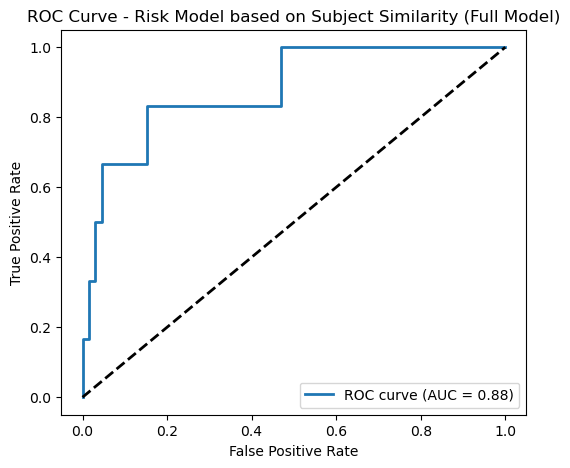

In [62]:
# 5. Plot ROC curve (train on full data and plot)
pipe.fit(sim_normalized.reshape(-1, 1), y)
y_pred_prob = pipe.predict_proba(sim_normalized.reshape(-1, 1))[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = roc_auc_score(y, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Risk Model based on Subject Similarity (Full Model)')
plt.legend(loc='lower right')
plt.show()

In [31]:
# 6. Bootstrap to calculate confidence interval and p-value for AUC
n_bootstraps = 1000
bootstrapped_scores = []
rng = np.random.RandomState(42)
for i in range(n_bootstraps):
    indices = rng.randint(0, len(y), len(y))
    if len(np.unique(y[indices])) < 2:
        continue
    score = roc_auc_score(y[indices], y_pred_prob[indices])
    bootstrapped_scores.append(score)
bootstrapped_scores = np.array(bootstrapped_scores)
bootstrapped_scores.sort()
ci_lower = bootstrapped_scores[int(0.025 * len(bootstrapped_scores))]
ci_upper = bootstrapped_scores[int(0.975 * len(bootstrapped_scores))]
se_auc = np.std(bootstrapped_scores)

z = (roc_auc - 0.5) / se_auc
p_value = 2 * (1 - norm.cdf(np.abs(z)))

print(f'AUC: {roc_auc:.3f}, CI: [{ci_lower:.3f}, {ci_upper:.3f}], p-value: {p_value:.3f}')


AUC: 0.881, CI: [0.705, 0.993], p-value: 0.000


Good Results!

# Feature Selection 

## (Failed due to Multicollinear)

/var/folders/ms/h0q9059n6w16qz8vp90k6zlh0000gn/T/ipykernel_33608/2459576884.py:15: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  region_avg_df = final_features_df.groupby(by=lambda col: extract_region(col), axis=1).mean()


New feature matrix shape (per region): (72, 167)
Baseline Accuracy (region-average features): 1.000
Top 20 regions by permutation importance:
                            feature  importance  std
0                       AVLT_Trial6         0.0  0.0
105                 rh_V1_exvivo_fa         0.0  0.0
107                 rh_V2_exvivo_fa         0.0  0.0
108          rh_V2_exvivo_thresh_fa         0.0  0.0
109            rh_cortex+hipamyg_fa         0.0  0.0
110                    rh_cortex_fa         0.0  0.0
111         rh_entorhinal_exvivo_fa         0.0  0.0
112  rh_entorhinal_exvivo_thresh_fa         0.0  0.0
113             rh_hOc1_mpm_vpnl_fa         0.0  0.0
114             rh_hOc2_mpm_vpnl_fa         0.0  0.0
115            rh_hOc3v_mpm_vpnl_fa         0.0  0.0
116            rh_hOc4v_mpm_vpnl_fa         0.0  0.0
117              rh_nofix_cortex_fa         0.0  0.0
118         rh_perirhinal_exvivo_fa         0.0  0.0
119  rh_perirhinal_exvivo_thresh_fa         0.0  0.0
120       

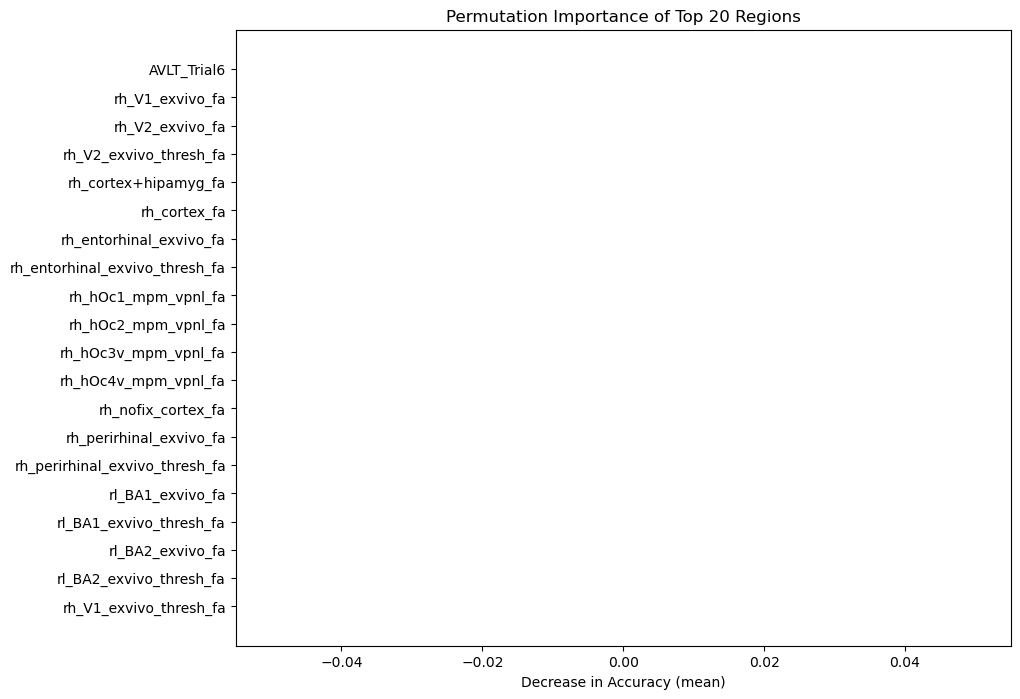

In [61]:
import re
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt


# Define a function to extract the region identifier (e.g., "lh_BA1_exvivo_fa_d1" -> "lh_BA1_exvivo_fa")
def extract_region(col_name):
    return re.sub(r'_d\d+$', '', col_name)

# Use groupby to group columns by region and calculate the mean
region_avg_df = final_features_df.groupby(by=lambda col: extract_region(col), axis=1).mean()
print("New feature matrix shape (per region):", region_avg_df.shape)

# Next, use region_avg_df to calculate Permutation Importance
# Split into training and testing sets
X = region_avg_df.values  # New feature matrix, each feature represents a region (or hemisphere+region)
y = y_bin
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=23, test_size=0.3)

# Build a pipeline (standardization + logistic regression)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=22))
])
pipe.fit(X, y)
baseline_score = pipe.score(X, y)
print(f"Baseline Accuracy (region-average features): {baseline_score:.3f}")

# Compute Permutation Importance (using accuracy as the scoring metric)
result = permutation_importance(pipe, X_test, y_test, n_repeats=3, random_state=1, scoring='accuracy')
importances = result.importances_mean
importances_std = result.importances_std

# Save results to a DataFrame, with row indices being the region names (i.e., columns of region_avg_df)
importance_df = pd.DataFrame({
    'feature': region_avg_df.columns,
    'importance': importances,
    'std': importances_std
}).sort_values(by='importance', ascending=False)

print("Top 20 regions by permutation importance:")
print(importance_df.head(20))

# Plot a bar chart to show the top 20 most important regions
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'].head(20), importance_df['importance'].head(20), xerr=importance_df['std'].head(20))
plt.gca().invert_yaxis()
plt.xlabel("Decrease in Accuracy (mean)")
plt.title("Permutation Importance of Top 20 Regions")
plt.show()


Baseline Accuracy: 0.818
Top 20 features by permutation importance:
                         feature  importance  std
0     lh_BA1_exvivo_thresh_fa_d1         0.0  0.0
1673        rl_BA1_exvivo_fa_d15         0.0  0.0
1666         rl_BA1_exvivo_fa_d8         0.0  0.0
1667         rl_BA1_exvivo_fa_d9         0.0  0.0
1668        rl_BA1_exvivo_fa_d10         0.0  0.0
1669        rl_BA1_exvivo_fa_d11         0.0  0.0
1670        rl_BA1_exvivo_fa_d12         0.0  0.0
1671        rl_BA1_exvivo_fa_d13         0.0  0.0
1672        rl_BA1_exvivo_fa_d14         0.0  0.0
1674        rl_BA1_exvivo_fa_d16         0.0  0.0
1683  rl_BA2_exvivo_thresh_fa_d4         0.0  0.0
1675        rl_BA1_exvivo_fa_d17         0.0  0.0
1676        rl_BA1_exvivo_fa_d18         0.0  0.0
1677        rl_BA1_exvivo_fa_d19         0.0  0.0
1678        rl_BA1_exvivo_fa_d20         0.0  0.0
1679        rl_BA1_exvivo_fa_d21         0.0  0.0
1680  rl_BA2_exvivo_thresh_fa_d1         0.0  0.0
1681  rl_BA2_exvivo_thresh_fa_d2

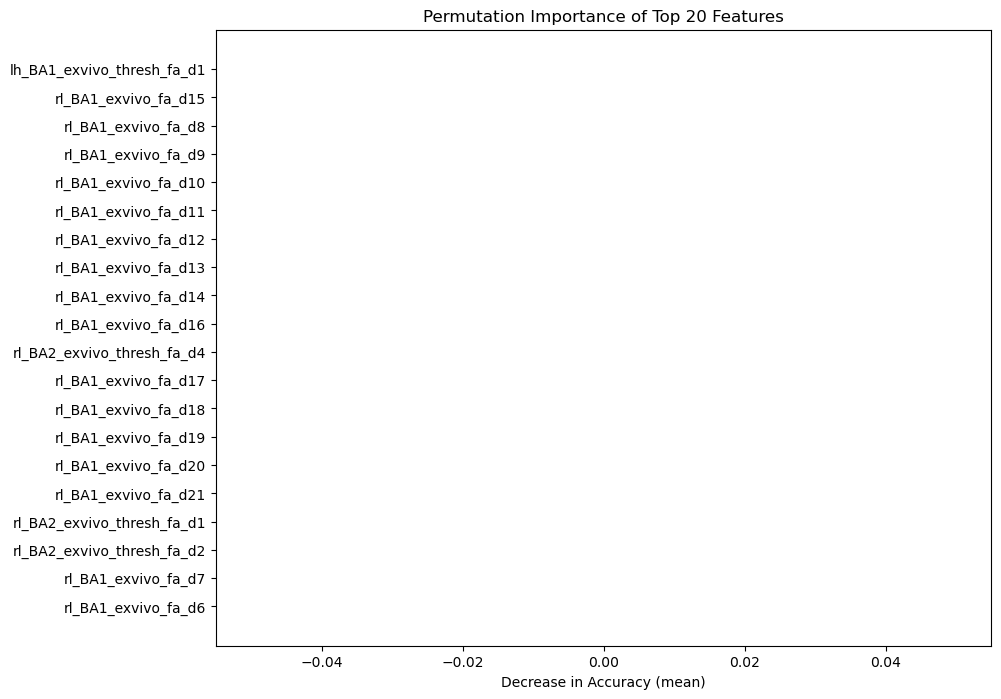

In [45]:
X = final_features_df.values   # shape: (n_samples, 2507)
y = y_bin
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

# Build the pipeline (first standardize, then apply Logistic Regression)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
pipe.fit(X_train, y_train)
baseline_score = pipe.score(X_test, y_test)
print(f"Baseline Accuracy: {baseline_score:.3f}")

# Compute Permutation Importance (using accuracy as the scoring metric)
result = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importances = result.importances_mean
importances_std = result.importances_std

# Store the results in a DataFrame, assuming final_features_df.columns contains the feature names
importance_df = pd.DataFrame({
    'feature': final_features_df.columns,
    'importance': importances,
    'std': importances_std
}).sort_values(by='importance', ascending=False)

print("Top 20 features by permutation importance:")
print(importance_df.head(20))

# If the same variable has multiple measures (e.g., feature names like "regionX_binY"), you can group by prefix:
def get_prefix(feature_name):
    # Assuming feature names are separated by "_", and the first part is the variable prefix
    return feature_name.split('_')[0]

importance_df['prefix'] = importance_df['feature'].apply(get_prefix)
grouped_importance = importance_df.groupby('prefix').agg({'importance': 'mean', 'std': 'mean'}).sort_values(by='importance', ascending=False)
print("Grouped feature importance (by prefix):")
print(grouped_importance.head(20))

# Plot the importance bar chart for the top 20 individual features
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'].head(20), importance_df['importance'].head(20), xerr=importance_df['std'].head(20))
plt.gca().invert_yaxis()
plt.xlabel("Decrease in Accuracy (mean)")
plt.title("Permutation Importance of Top 20 Features")
plt.show()


## SHAP

In [55]:
import shap
import matplotlib.pyplot as plt

# Split training and testing sets, and build the Pipeline model
# ---------------------------
y = y_bin
X = region_avg_df
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=12345, test_size=0.3)

# Pipeline: Standardize first, then apply Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=100, random_state=2))
])
pipe.fit(X_train, y_train)
print(f"Baseline Accuracy: {pipe.score(X_test, y_test):.3f}")

# ---------------------------
# 3. Compute SHAP values (use LinearExplainer for linear models)
# ---------------------------
# Since the Pipeline includes StandardScaler, apply the transformation manually to the training data
X_train_scaled = pipe.named_steps['scaler'].transform(X_train)
X_test_scaled = pipe.named_steps['scaler'].transform(X_test)

# Use LinearExplainer to interpret the Logistic Regression model
explainer = shap.LinearExplainer(pipe.named_steps['clf'], X_train_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled)


Baseline Accuracy: 0.955


/Users/shixuan/anaconda3/lib/python3.11/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


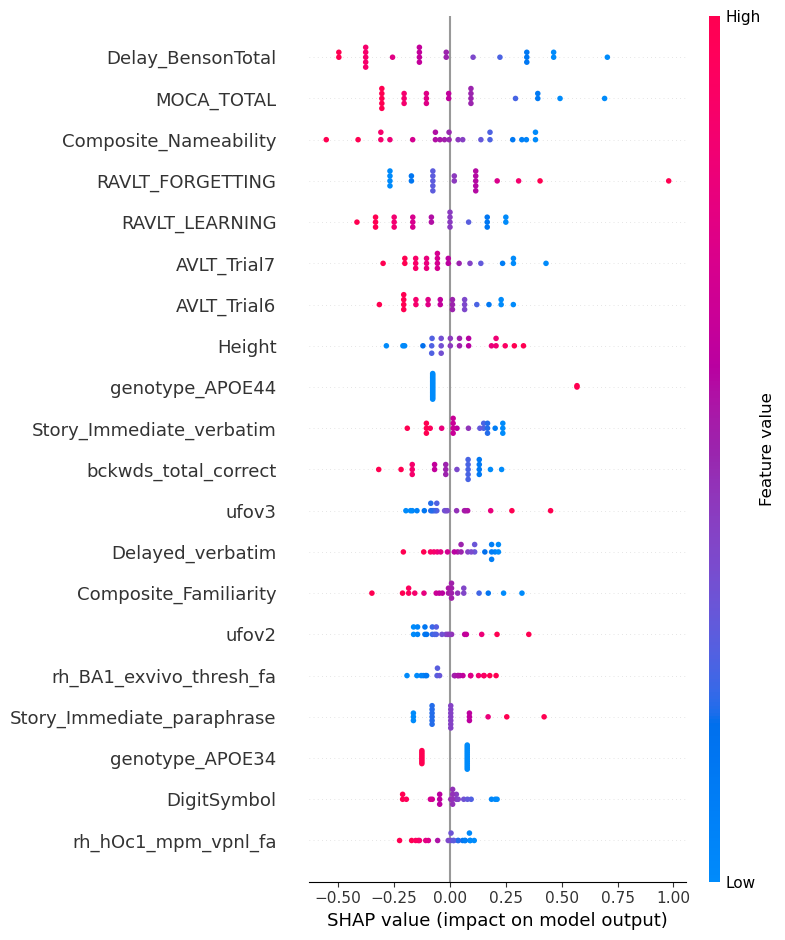

In [56]:
shap.summary_plot(shap_values, X_test)

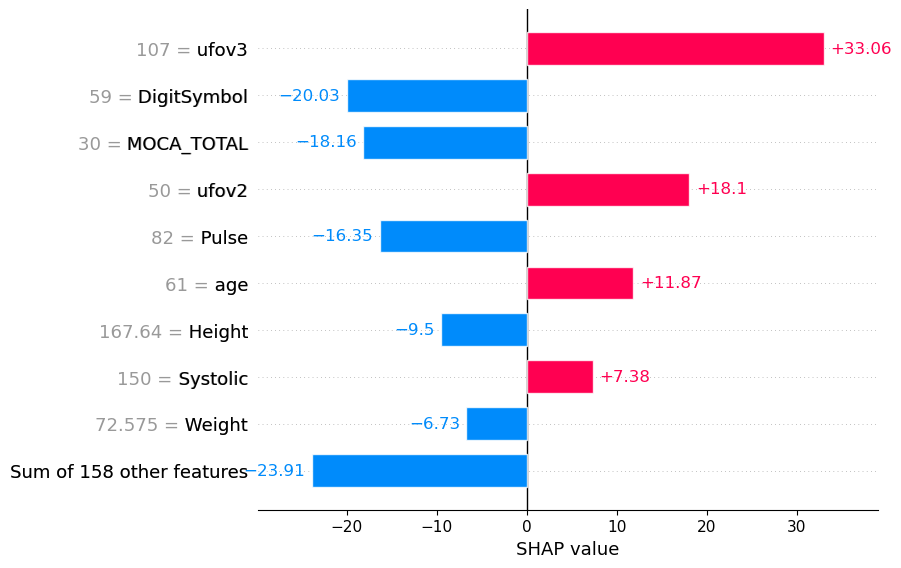

In [52]:
shap.plots.bar(shap_values[1])

## hierarchical clustering on the Spearman rank-order correlations

reference: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html#sphx-glr-auto-examples-inspection-plot-permutation-importance-multicollinear-py

Text(0.5, 1.0, 'Absolute Spearman Correlation Heatmap')

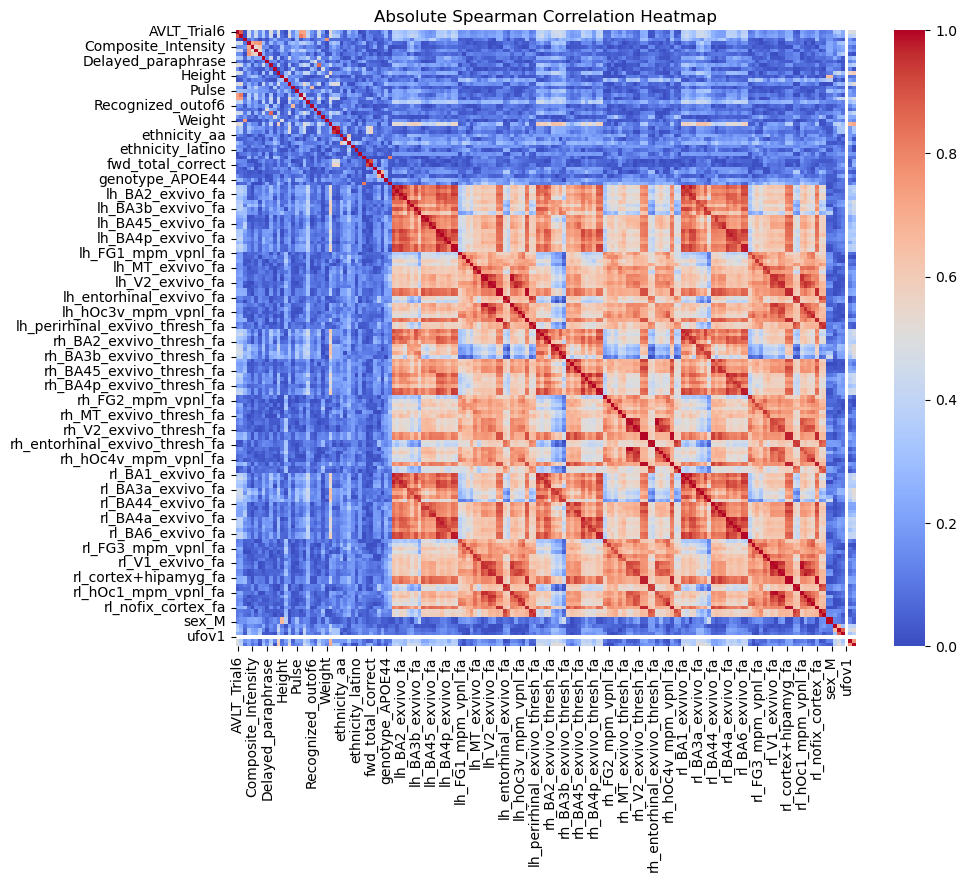

In [130]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# ---------------------------
# 1. Compute Spearman correlation between features and take the absolute value
# ---------------------------
corr = region_avg_df.corr(method='spearman').abs()

# Optional: plot a heatmap of the correlation matrix to inspect multicollinearity
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', vmax=1.0, vmin=0.0)
plt.title("Absolute Spearman Correlation Heatmap")

In [131]:
from scipy.stats import spearmanr 
from scipy.spatial.distance import squareform 
from scipy.stats import spearmanr

#corr = spearmanr(region_avg_df).correlation
corr = region_avg_df.corr(method='spearman')  

In [132]:
distance_matrix = 1 - corr.abs()

distance_matrix = (distance_matrix + distance_matrix.T) / 2
np.fill_diagonal(distance_matrix.values, 0)


In [133]:
# 'ufov1' : all NaN
distance_matrix_clean = distance_matrix.drop(columns=['ufov1'], index = ['ufov1'])

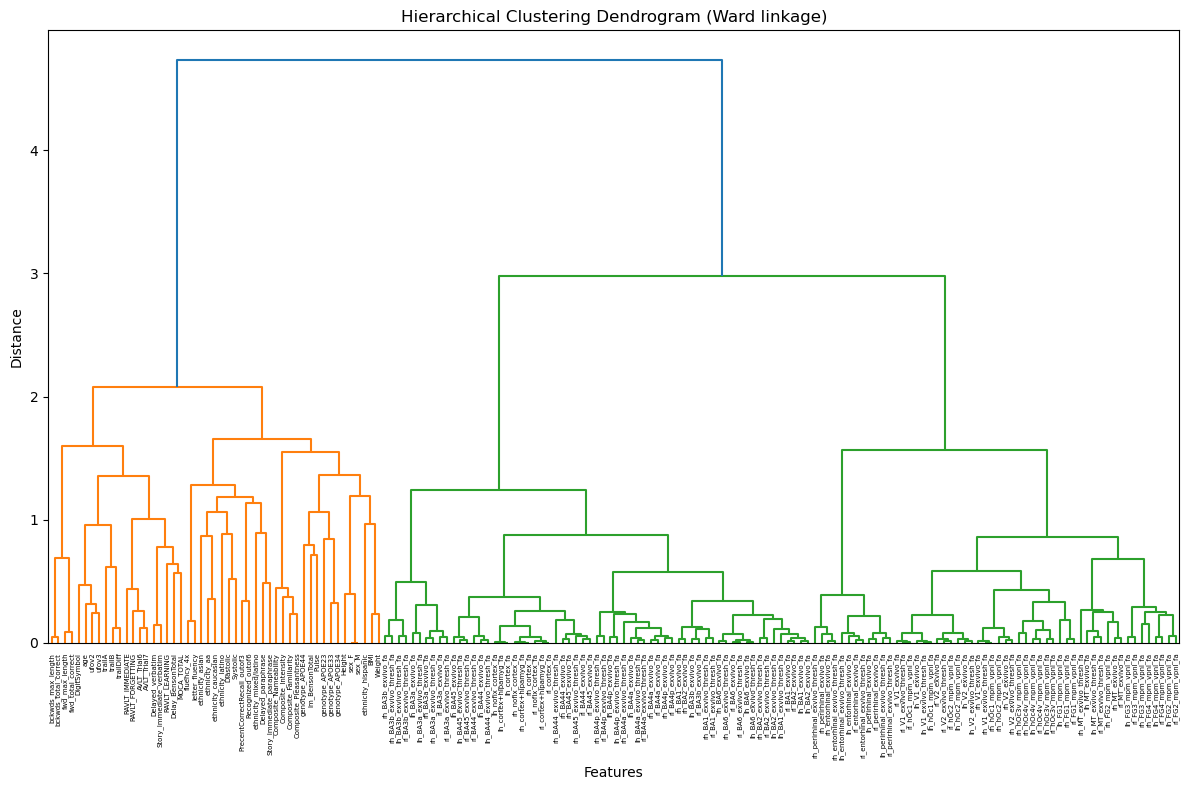

In [134]:
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy

# Convert the symmetric distance matrix to condensed format
condensed_dist = squareform(distance_matrix_clean.values)

# Perform hierarchical clustering (e.g., method='ward')
Z = hierarchy.linkage(condensed_dist, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendro = hierarchy.dendrogram(Z, labels=distance_matrix_clean.columns.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Features")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [135]:
### Set Threshold!!!!!
threshold = 2
cluster_labels = hierarchy.fcluster(Z, t=threshold, criterion='distance')

clusters_df = pd.DataFrame({'feature': distance_matrix_clean.columns, 'cluster': cluster_labels})
clusters_df.sort_values('cluster', inplace=True)
print(clusters_df.head(len(clusters_df)))


                feature  cluster
0           AVLT_Trial6        1
163           trailDiff        1
162              trailB        1
161              trailA        1
164               ufov2        1
..                  ...      ...
101  rh_FG3_mpm_vpnl_fa        4
100  rh_FG2_mpm_vpnl_fa        4
99   rh_FG1_mpm_vpnl_fa        4
107     rh_V2_exvivo_fa        4
62   lh_FG3_mpm_vpnl_fa        4

[166 rows x 2 columns]


### Set Threshold！

In [147]:
selected_features = []
# Iterate over each cluster ID
for c in clusters_df['cluster'].unique():
    # Get all feature names in the current cluster
    cluster_feats = clusters_df.loc[clusters_df['cluster'] == c, 'feature'].values
    # Select all entries in importance_df that correspond to these features
    cluster_importances = importance_df[importance_df['feature'].isin(cluster_feats)]
    # Sort by importance and select the top one
    rep_feat = cluster_importances.sort_values('importance', ascending=False)['feature'].iloc[0]
    selected_features.append(rep_feat)

print("Selected representative features (by highest permutation importance in each cluster):")
print(selected_features)


Selected representative features (by highest permutation importance in each cluster):
['AVLT_Trial6', 'sex_F', 'rh_cortex+hipamyg_fa', 'rh_V1_exvivo_fa']


Distance stats: 35433.65338685017 25004.449340083753


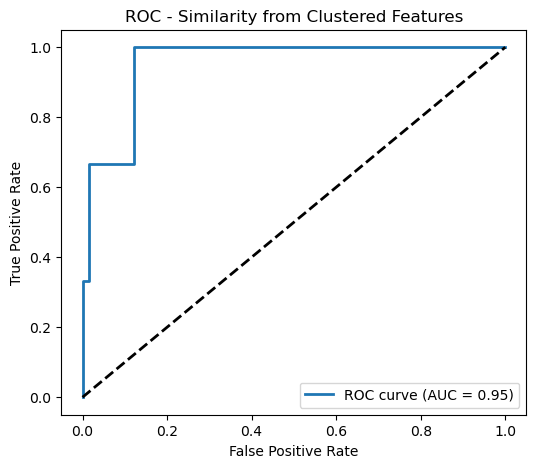

Predictor: Similarity (Clustered Features), AUC: 0.955, CI: [0.890, 1.000], p-value: 0.000


In [149]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from metric_learn import NCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========== 3) Keep only selected features from region_avg_df and apply the NCA-based similarity pipeline ==========
X_sel = region_avg_df[selected_features].copy()
y_arr = y_bin  # (n_samples, )

# 3.1 Train NCA metric function
nca_model = NCA(random_state=42)
nca_model.fit(X_sel.values, y_arr)
metric_fun = nca_model.get_metric()

# 3.2 Find risky group samples (y == 1) and compute their average vector
risk_mask = (final_y == 1)
X_sel_risk = X_sel.values[risk_mask]
avg_risk_vector = np.mean(X_sel_risk, axis=0)  # (len(selected_features),)

# 3.3 Compute distance between each sample and the average vector of the risky group
def metric_distance(x, y, metric):
    return metric(x, y)

distances = []
for row in X_sel.values:
    d = metric_distance(row, avg_risk_vector, metric_fun)
    distances.append(d)

distances = np.array(distances)
print("Distance stats:", distances.mean(), distances.std())

# 3.4 Convert distance to similarity = 1 / distance, then normalize to [0,1]
similarity = 1 / distances
similarity_norm = similarity / similarity.max()

df_similarity = pd.DataFrame({
    'similarity': similarity_norm,
    'risk_label': y_bin
}, index=X_sel.index)

# ========== 4) Use similarity for Logistic Regression and compute AUC ==========
y_target = df_similarity['risk_label'].values
X_sim = df_similarity[['similarity']].values

pipe_sim = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_sim.fit(X_sim, y_bin)
y_pred_prob = pipe_sim.predict_proba(X_sim)[:, 1]

fpr, tpr, thresholds = roc_curve(y_bin, y_pred_prob)
roc_auc = roc_auc_score(y_bin, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Similarity from Clustered Features')
plt.legend(loc='lower right')
plt.show()

# Optional: Bootstrap to compute confidence interval for AUC
n_bootstraps = 1000
rng = np.random.RandomState(42)
boot_scores = []
for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_target), len(y_target))
    if len(np.unique(y_target[indices])) < 2:
        continue
    score = roc_auc_score(y_target[indices], y_pred_prob[indices])
    boot_scores.append(score)

boot_scores = np.array(boot_scores)
boot_scores.sort()
ci_lower = boot_scores[int(0.025 * len(boot_scores))]
ci_upper = boot_scores[int(0.975 * len(boot_scores))]
se_auc = np.std(boot_scores)
z_val = (roc_auc - 0.5) / se_auc
p_value = 2 * (1 - norm.cdf(abs(z_val)))

print(f"Predictor: Similarity (Clustered Features), AUC: {roc_auc:.3f}, CI: [{ci_lower:.3f}, {ci_upper:.3f}], p-value: {p_value:.3f}")


Accuracy on test data with selected features: 0.94


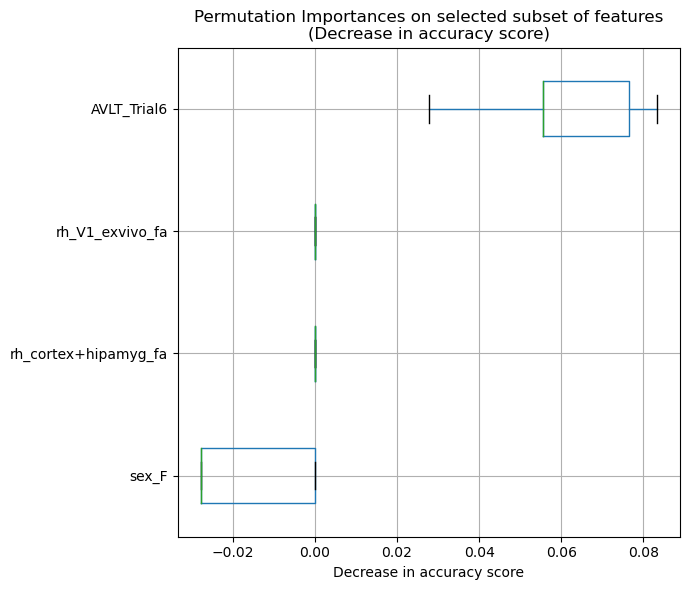

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_sel = region_avg_df[selected_features]

# Split into training and testing sets
X_train_sel, X_test_sel, y_train, y_test = train_test_split(
    X_sel, y, stratify=y, random_state=42, test_size=0.5
)

# Train a model (using Logistic Regression here as an example)
clf_sel = LogisticRegression(max_iter=1000, random_state=42)
clf_sel.fit(X_train_sel, y_train)
print(f"Accuracy on test data with selected features: {clf_sel.score(X_test_sel, y_test):.2f}")

# Compute Permutation Importance
result = permutation_importance(
    estimator=clf_sel,
    X=X_test_sel,
    y=y_test,
    n_repeats=10,            
    random_state=42,
    scoring='accuracy'       # Decrease in accuracy
)

# result.importances shape: (n_features, n_repeats)
importances = result.importances
features = X_test_sel.columns

df_box = pd.DataFrame(importances, index=features)

# Sort features by mean importance
mean_importance = df_box.mean(axis=1)
sorted_idx = mean_importance.argsort()

fig, ax = plt.subplots(figsize=(7, 6))
# Plot boxplot: features sorted by mean importance in ascending order
df_box_sorted = df_box.iloc[sorted_idx]
df_box_sorted.T.boxplot(
    vert=False,      # Horizontal boxplot
    labels=df_box_sorted.index
)
ax.set_title("Permutation Importances on selected subset of features\n(Decrease in accuracy score)")
ax.set_xlabel("Decrease in accuracy score")
fig.tight_layout()
plt.show()